In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
import pandas as pd
import numpy as np

# Ensure scripts directory is accessible
sys.path.append(os.path.abspath('../'))
from scripts.forecast_models import safe_load_processed_data, optimize_portfolio

# SYSTEMATIC ERROR HANDLING LAYER
returns_df = safe_load_processed_data('../data/processed/daily_returns.csv')
tsla_forecast = safe_load_processed_data('../data/processed/tsla_future_forecast.csv', is_forecast=True)

# Calculate expected annualized returns vector
tsla_start_val = tsla_forecast['Price'].iloc[0]
tsla_end_val = tsla_forecast['Price'].iloc[-1]
tsla_expected_return = (tsla_end_val - tsla_start_val) / tsla_start_val

spy_expected_return = returns_df['SPY'].mean() * 252
bnd_expected_return = returns_df['BND'].mean() * 252

expected_returns = np.array([bnd_expected_return, spy_expected_return, tsla_expected_return])
cov_matrix = returns_df.cov()
assets = ['BND', 'SPY', 'TSLA']

print("=== EXPECTED ANNUALIZED RETURNS VECTOR ===")
for asset, ret in zip(assets, expected_returns):
    print(f"{asset}: {ret*100:.2f}%")

=== EXPECTED ANNUALIZED RETURNS VECTOR ===
BND: -1.11%
SPY: 17.69%
TSLA: 0.15%


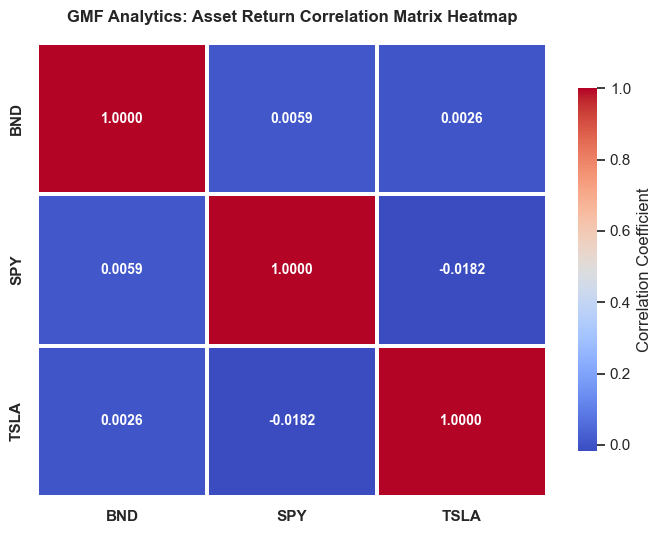

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configure production-grade styling aesthetics
sns.set_theme(style="white")
plt.figure(figsize=(7, 5.5))

# 2. Plot the upgraded heatmap with precise formatting bounds
sns.heatmap(
    returns_df.corr(), 
    annot=True, 
    cmap='coolwarm', 
    fmt=".4f", 
    linewidths=1.5, 
    linecolor='white',
    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
    annot_kws={"size": 10, "weight": "bold"}
)

# 3. Add explicit titles and styling layout
plt.title("GMF Analytics: Asset Return Correlation Matrix Heatmap", fontsize=12, fontweight='bold', pad=15)
plt.xticks(weight='bold')
plt.yticks(weight='bold')
plt.tight_layout()
plt.show()

In [4]:
import sys
import os

# Ensure the scripts directory is in your path
sys.path.append(os.path.abspath('../'))

# Explicitly import the functions from your scripts folder
from scripts.forecast_models import optimize_portfolio, calculate_portfolio_performance

print("✅ Optimization functions successfully imported!")

✅ Optimization functions successfully imported!


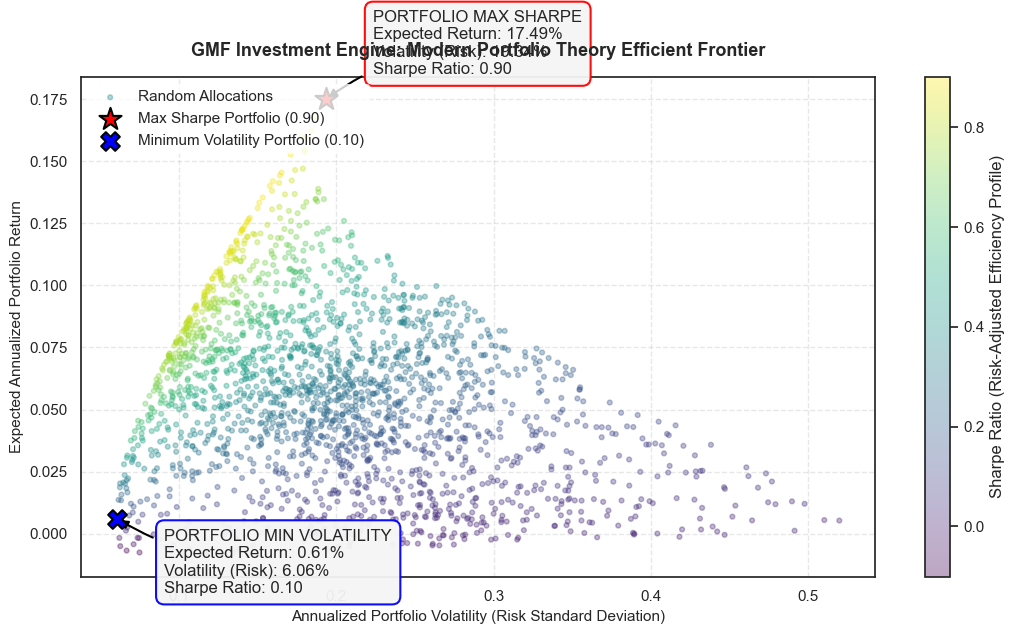

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Optimize the two target portfolios
max_sharpe_w = optimize_portfolio(expected_returns, cov_matrix, objective='sharpe')
min_vol_w = optimize_portfolio(expected_returns, cov_matrix, objective='volatility')

# 2. Calculate explicit performance profiles
max_s_ret, max_s_vol, max_s_sr = calculate_portfolio_performance(max_sharpe_w, expected_returns, cov_matrix)
min_v_ret, min_v_vol, min_v_sr = calculate_portfolio_performance(min_vol_w, expected_returns, cov_matrix)

# 3. Simulate 2,000 random portfolios to plot the full Efficient Frontier cloud
num_portfolios = 2000
results = np.zeros((3, num_portfolios))
np.random.seed(42)

for i in range(num_portfolios):
    weights = np.random.random(len(assets))
    weights /= np.sum(weights)
    p_ret, p_vol, _ = calculate_portfolio_performance(weights, expected_returns, cov_matrix)
    results[0, i] = p_vol
    results[1, i] = p_ret
    results[2, i] = p_ret / p_vol

# 4. Plot optimization boundaries with professional aesthetics
plt.figure(figsize=(11, 6.5))
sc = plt.scatter(results[0,:], results[1,:], c=results[2,:], cmap='viridis', marker='o', s=12, alpha=0.35, label='Random Allocations')
plt.colorbar(sc, label='Sharpe Ratio (Risk-Adjusted Efficiency Profile)')

# 5. Highlight and ANNOTATE Max Sharpe Portfolio (The Star)
plt.scatter(max_s_vol, max_s_ret, color='red', marker='*', s=280, edgecolors='black', linewidths=1.5, zorder=5, label=f'Max Sharpe Portfolio ({max_s_sr:.2f})')
plt.annotate(
    f'PORTFOLIO MAX SHARPE\nExpected Return: {max_s_ret*100:.2f}%\nVolatility (Risk): {max_s_vol*100:.2f}%\nSharpe Ratio: {max_s_sr:.2f}',
    xy=(max_s_vol, max_s_ret), 
    xytext=(max_s_vol + 0.03, max_s_ret + 0.01),
    bbox=dict(boxstyle="round,pad=0.5", fc="whitesmoke", ec="red", lw=1.5, alpha=0.95),
    arrowprops=dict(arrowstyle="-|>", connectionstyle="arc3,rad=0.15", color="black", lw=1.5)
)

# 6. Highlight and ANNOTATE Minimum Volatility Portfolio (The X)
plt.scatter(min_v_vol, min_v_ret, color='blue', marker='X', s=180, edgecolors='black', linewidths=1.5, zorder=5, label=f'Minimum Volatility Portfolio ({min_v_sr:.2f})')
plt.annotate(
    f'PORTFOLIO MIN VOLATILITY\nExpected Return: {min_v_ret*100:.2f}%\nVolatility (Risk): {min_v_vol*100:.2f}%\nSharpe Ratio: {min_v_sr:.2f}',
    xy=(min_v_vol, min_v_ret), 
    xytext=(min_v_vol + 0.03, min_v_ret - 0.03),
    bbox=dict(boxstyle="round,pad=0.5", fc="whitesmoke", ec="blue", lw=1.5, alpha=0.95),
    arrowprops=dict(arrowstyle="-|>", connectionstyle="arc3,rad=-0.15", color="black", lw=1.5)
)

# 7. Refined chart styling details
plt.title("GMF Investment Engine: Modern Portfolio Theory Efficient Frontier", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Annualized Portfolio Volatility (Risk Standard Deviation)", fontsize=11)
plt.ylabel("Expected Annualized Portfolio Return", fontsize=11)
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
plt.grid(True, linestyle='--', alpha=0.45)
plt.tight_layout()
plt.show()

In [8]:
recommendation_data = {
    "Allocation Asset Weights": [
        f"BND: {max_sharpe_w[0]*100:.1f}% | SPY: {max_sharpe_w[1]*100:.1f}% | TSLA: {max_sharpe_w[2]*100:.1f}%",
        f"BND: {min_vol_w[0]*100:.1f}% | SPY: {min_vol_w[1]*100:.1f}% | TSLA: {min_vol_w[2]*100:.1f}%"
    ],
    "Expected Annual Return": [f"{max_s_ret*100:.2f}%", f"{min_v_ret*100:.2f}%"],
    "Expected Volatility": [f"{max_s_vol*100:.2f}%", f"{min_v_vol*100:.2f}%"],
    "Sharpe Ratio": [round(max_s_sr, 2), round(min_v_sr, 2)]
}

summary_df = pd.DataFrame(recommendation_data, index=["Maximum Sharpe Portfolio (Recommended)", "Minimum Volatility Portfolio"])
display(summary_df)

,Allocation Asset Weights,Expected Annual Return,Expected Volatility,Sharpe Ratio
Maximum Sharpe Portfolio (Recommended),BND: 0.2% | SPY: 98.9% | TSLA: 0.9%,17.49%,19.34%,0.9
Minimum Volatility Portfolio,BND: 89.7% | SPY: 9.1% | TSLA: 1.2%,0.61%,6.06%,0.1
